# Individual Homework Assignment

**Student:** Farkas Martin  
**Assignment theme:** Pizza ratings and sales  
**Files used:** `data_task1_variant2.csv`, `data_task2_variant2.csv`, `data_task3_variant2.csv`

This notebook contains my statistical analysis for the three assigned tasks. I use a significance level of `alpha = 0.05` throughout unless stated otherwise.


# AI Assistance Disclosure

In preparing this submission I used AI tools as coding and writing assistants:

- **OpenAI Codex (GPT 5.5 high, OpenAI)** was used to help draft the statistical analysis code (data loading, model fitting with `statsmodels` / `scipy`, diagnostic tests, and forecast plots) and to assist in drafting the written interpretations of the numerical results.
- **Claude Code (Claude Opus 4.7 max, Anthropic)** was used to review the notebook, cross-check the numerical outputs against the task descriptions, and refine the explanations.

All statistical choices (test selection, model specifications, significance level, interpretation of multicollinearity, model comparison) were reviewed by me, and I take full responsibility for the content of this submission. I am prepared to defend each method, assumption, and numerical result in the oral defence as required by Section 7 of the submission guidelines.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True})

alpha = 0.05


## Task 1 - One-way comparison of pizza rating means

The response variable is `Score`, a customer rating on a 0-10 scale. The factor is `Group`, the pizza type, which has five levels (Margherita, Pepperoni, Hawaiian, Quattro Formaggi, Vegetarian).

**Why one-way ANOVA?** I want to compare more than two independent group means on a continuous response, which is exactly what one-way ANOVA is designed for. A naive alternative would be to run all ten pairwise two-sample t-tests, but that would inflate the family-wise type I error rate: with ten comparisons each at level $0.05$, the probability of at least one false rejection under the global null would be up to about $1 - 0.95^{10} \approx 0.40$. ANOVA gives a single omnibus test with controlled type I error.

**Hypotheses:**

- $H_0:\ \mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5$, i.e. all five population mean scores are equal.
- $H_1:$ at least one $\mu_i$ differs from the rest. This alternative is composite; it does not specify which group differs or in which direction.

**ANOVA assumptions and why they matter:**

1. *Independence of observations* - a design assumption that cannot be tested without information about how the ratings were collected. I assume different customers rated independently. Violations (e.g. clustered ratings) would invalidate the $F$ distribution of the test statistic.
2. *Approximately normal residuals within each group* - the $F$ statistic is the ratio of two scaled chi-squared quantities, which follows an exact $F$ distribution only when residuals are normal. With 50 observations per group the central limit theorem makes ANOVA fairly robust, but I check anyway using the Shapiro-Wilk test on the model residuals.
3. *Approximately equal variances across groups* (homoscedasticity) - the $F$ test pools the within-group variance into a single estimate $MS_{\text{within}}$, so unequal variances bias the test. I check with Levene's test (median-centered, which is the Brown-Forsythe variant and is robust to non-normality) and confirm the conclusion with a Welch ANOVA, which does not assume equal variances.


,n,mean,sd,median,min,max
Group,,,,,,
Hawaiian,50,5.7730,1.4769,5.690,2.31,8.78
Margherita,50,5.4680,1.6207,5.560,0.64,8.70
Pepperoni,50,5.5484,1.1613,5.505,3.33,8.64
Quattro Formaggi,50,5.4270,1.6058,5.540,2.40,8.59
Vegetarian,50,5.4034,1.5942,5.260,2.05,10.00


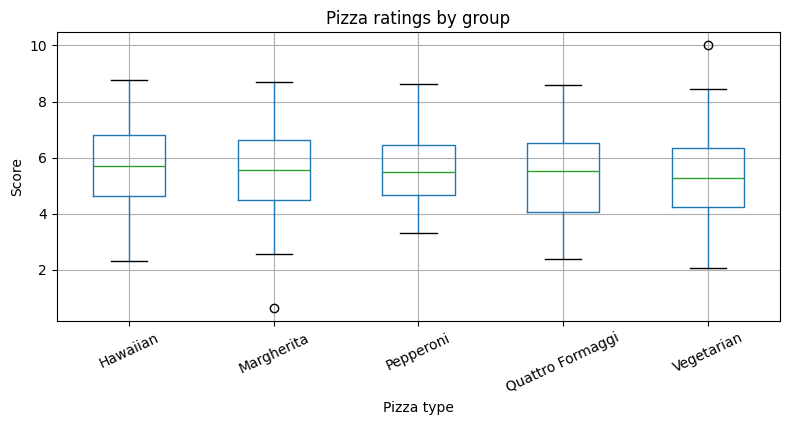

In [2]:
df1 = pd.read_csv("data/data_task1_variant2.csv")
summary1 = (
    df1.groupby("Group")["Score"]
    .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
    .sort_index()
)
display(summary1)

fig, ax = plt.subplots()
df1.boxplot(column="Score", by="Group", ax=ax, rot=25)
ax.set_title("Pizza ratings by group")
ax.set_xlabel("Pizza type")
ax.set_ylabel("Score")
plt.suptitle("")
plt.tight_layout()
plt.show()


The sample is balanced, with $n_i = 50$ ratings in each of the five groups. A balanced design is desirable here because it makes ANOVA most robust to mild violations of the equal-variance assumption and gives equal precision to each group mean estimate.

The five group means are all close together, ranging from about `5.40` (Vegetarian) to `5.77` (Hawaiian) on a 0-10 scale, a spread of only about `0.37` rating points. The within-group standard deviations range from about `1.16` (Pepperoni) to `1.62` (Margherita); the ratio of largest to smallest is about `1.4`, which is well within the rule-of-thumb factor of 2 for using classical ANOVA. The boxplot supports the same impression: the median lines, boxes, and whiskers overlap substantially across the five pizza types, so before any formal testing there is no visually dramatic difference between groups.


In [3]:
anova_model = smf.ols("Score ~ C(Group)", data=df1).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
display(anova_table)

ss_between = anova_table.loc["C(Group)", "sum_sq"]
ss_within = anova_table.loc["Residual", "sum_sq"]
ss_total = ss_between + ss_within
df_between = anova_table.loc["C(Group)", "df"]
ms_within = anova_table.loc["Residual", "sum_sq"] / anova_table.loc["Residual", "df"]
eta_sq = ss_between / ss_total
omega_sq = max((ss_between - df_between * ms_within) / (ss_total + ms_within), 0)
effect_sizes1 = pd.DataFrame({"effect_size": ["eta-squared", "omega-squared"], "value": [eta_sq, omega_sq]})
display(effect_sizes1)

group_arrays = [g["Score"].to_numpy() for _, g in df1.groupby("Group")]
assumption_checks1 = pd.DataFrame(
    {
        "check": ["Levene test for equal variances", "Shapiro-Wilk test for ANOVA residual normality"],
        "statistic": [
            stats.levene(*group_arrays, center="median").statistic,
            stats.shapiro(anova_model.resid).statistic,
        ],
        "p_value": [
            stats.levene(*group_arrays, center="median").pvalue,
            stats.shapiro(anova_model.resid).pvalue,
        ],
    }
)
display(assumption_checks1)

welch = anova_oneway(group_arrays, use_var="unequal")
print(f"Welch robustness check: F = {welch.statistic:.4f}, df = ({welch.df_num:.0f}, {welch.df_denom:.2f}), p = {welch.pvalue:.4f}")


,sum_sq,df,F,PR(>F)
C(Group),4.4843,4.0,0.4971,0.7379
Residual,552.5469,245.0,NaN,NaN


,effect_size,value
0,eta-squared,0.0081
1,omega-squared,0.0000


,check,statistic,p_value
0,Levene test for equal variances,1.2871,0.2756
1,Shapiro-Wilk test for ANOVA residual normality,0.9960,0.7653


Welch robustness check: F = 0.4815, df = (4, 121.86), p = 0.7493


**ANOVA result.** The $F$ statistic is $F(4, 245) = $ `0.4971` with $p = $ `0.7379`. The numerator degrees of freedom ($k - 1 = 4$ for $k = 5$ groups) reflect the comparison of five means, and the denominator ($N - k = 250 - 5 = 245$) reflects the within-group residual information. The $F$ statistic is the ratio

$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}};$$

under $H_0$ both estimate the same residual variance, so $F$ should be near $1$. An observed $F$ well below $1$ is consistent with no group effect.

The p-value of `0.7379` means that, if the five population means were truly equal, observing a between-group signal at least this large would occur about 74% of the time by chance. Since $p > 0.05$, I **fail to reject $H_0$** and conclude that the data do not provide evidence that pizza-type means differ.

> *On the interpretation of "fail to reject".* Failing to reject is not the same as accepting $H_0$ as true. A test at significance level $\alpha$ controls only the **type I error rate** (the probability of rejecting $H_0$ when it is in fact true) at $\alpha = 0.05$. The probability of the opposite mistake - failing to reject when $H_0$ is in fact false - is the **type II error rate**, denoted $\beta$, and the **power** of the test is $1 - \beta$. Power depends on the unknown true effect size, the sample size $N$, and the chosen $\alpha$; it increases with all three. Here the sample is large ($N = 250$) and the observed effect size is tiny ($\eta^2 \approx 0.008$), so power against meaningfully large differences in mean is high; the non-rejection here is genuinely informative, not an underpowered failure to detect.

**Effect sizes.** Effect sizes complement the p-value with a sample-size-independent measure of practical importance:

- $\eta^2 = SS_{\text{between}} / SS_{\text{total}} \approx $ `0.0081` means group membership explains less than 1% of the variability in `Score`. This is the sample analogue of the population variance explained.
- $\omega^2 = (SS_{\text{between}} - df_{\text{between}} \cdot MS_{\text{within}}) / (SS_{\text{total}} + MS_{\text{within}})$ is a bias-corrected version of $\eta^2$; in small samples $\eta^2$ overestimates the population effect. Here it is truncated at zero, meaning the bias-corrected estimate of the true group effect is essentially nothing.

**Assumption checks.**

- *Levene's test* for equal variances has $p = $ `0.2756`. The null hypothesis of equal group variances is not rejected, so the homoscedasticity assumption is plausible.
- *Shapiro-Wilk test* on the ANOVA residuals (not on the raw scores; residuals are what ANOVA assumes to be normal) has $p = $ `0.7653`. Normality is not rejected.
- *Welch ANOVA* gives $F(4, 121.86) = $ `0.4815`, $p = $ `0.7493`. Welch's method uses a Satterthwaite correction to the denominator degrees of freedom (here about 122 instead of 245) precisely so that the test does not assume equal variances. The fact that Welch and classical ANOVA agree closely is a robustness reassurance: the conclusion does not hinge on the equal-variance assumption.


In [4]:
tukey = pairwise_tukeyhsd(endog=df1["Score"], groups=df1["Group"], alpha=alpha)
tukey_table = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
display(tukey_table)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Hawaiian,Margherita,-0.3050,0.8481,-1.1304,0.5204,False
1,Hawaiian,Pepperoni,-0.2246,0.9449,-1.0500,0.6008,False
2,Hawaiian,Quattro Formaggi,-0.3460,0.7785,-1.1714,0.4794,False
3,Hawaiian,Vegetarian,-0.3696,0.7335,-1.1950,0.4558,False
4,Margherita,Pepperoni,0.0804,0.9989,-0.7450,0.9058,False
5,Margherita,Quattro Formaggi,-0.0410,0.9999,-0.8664,0.7844,False
6,Margherita,Vegetarian,-0.0646,0.9995,-0.8900,0.7608,False
7,Pepperoni,Quattro Formaggi,-0.1214,0.9944,-0.9468,0.7040,False
8,Pepperoni,Vegetarian,-0.1450,0.9889,-0.9704,0.6804,False
9,Quattro Formaggi,Vegetarian,-0.0236,1.0000,-0.8490,0.8018,False


**Why Tukey HSD?** When the omnibus ANOVA is significant, the natural follow-up is to ask *which* groups differ. There are $\binom{5}{2} = 10$ pairwise comparisons. If I ran ten separate two-sample t-tests at level $\alpha = 0.05$, the family-wise type I error rate could rise to about 40%. Tukey's Honestly Significant Difference (HSD) is designed for exactly this situation: it builds simultaneous confidence intervals using the studentized range distribution so that the joint coverage of all ten intervals is $1 - \alpha = 0.95$. Equivalently, each adjusted p-value is the largest $\alpha$ at which that specific pair would still be rejected when the family-wise error rate is controlled at that level.

**Interpretation of the output.** Because the omnibus ANOVA was not significant, post-hoc claims are not formally warranted: running post-hoc tests after a non-significant omnibus inflates discovery rates and is methodologically discouraged. I include the Tukey table only as a consistency check.

The check is reassuring: every adjusted p-value is large (smallest is `0.7335` for Hawaiian vs. Vegetarian), every simultaneous 95% confidence interval contains zero, and every `reject` flag is `False`. So even if I ignored the omnibus and reported the post-hoc anyway, no pair of pizza types would be flagged as different at the 5% level. The mean differences themselves are tiny (largest $|\text{meandiff}| \approx 0.37$, well within the within-group standard deviations of about 1.5), so the pattern is "no detectable difference," not "underpowered detection of a real difference."

**Final answer for Task 1.** At significance level $\alpha = 0.05$ there is no statistical evidence that mean pizza ratings differ between the five groups, and there is therefore nothing for the post-hoc step to report.

## Task 2 - Multiple linear regression for weekly sales

The response is `Y`, the weekly number of pizzas sold. The two predictors are `X_1`, the price of the pizza in HUF, and `X_2`, the customer rating of the pizza. I fit the multiple linear regression model

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon,$$

estimated by ordinary least squares (OLS).

**Why OLS multiple linear regression?** The question asks for a fitted model linking a continuous response to two continuous predictors. OLS minimizes the sum of squared residuals

$$\sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_{i1} - \beta_2 x_{i2})^2.$$

In matrix form, with design matrix $X$ ($n \times (p+1)$, first column all ones) and response vector $y$, the OLS estimator is the solution of the **normal equations** $X^\top X \hat\beta = X^\top y$, giving

$$\hat\beta = (X^\top X)^{-1} X^\top y,$$

provided $X^\top X$ is invertible (i.e. no exact collinearity). Under the Gauss-Markov assumptions (linearity in parameters, $E[\varepsilon \mid X] = 0$, $\operatorname{Var}(\varepsilon \mid X) = \sigma^2 I$, errors uncorrelated) the OLS estimator is **BLUE**: the *Best (minimum-variance) Linear Unbiased Estimator* of $\beta$ within the class of estimators that are linear in $y$. If, in addition, errors are normal, $\hat\beta$ is also the maximum likelihood estimator and the $t$ and $F$ test statistics follow exact $t$ and $F$ distributions, giving exact small-sample inference.

The standard errors of the coefficient estimates come from the covariance matrix

$$\operatorname{Var}(\hat\beta \mid X) = \sigma^2 (X^\top X)^{-1},$$

estimated by replacing $\sigma^2$ with $\hat\sigma^2 = MS_{\text{residual}}$. The diagonal entries give $\operatorname{SE}(\hat\beta_j)^2$, which enter both the $t$ statistics and the confidence intervals.

**Model assumptions on $\varepsilon$:**

1. $E[\varepsilon \mid X] = 0$ - the model is correctly specified; no omitted nonlinearity systematically biases the fit.
2. $\operatorname{Var}(\varepsilon \mid X) = \sigma^2$ - homoscedasticity; needed so that the SE formulas for the coefficients are valid. I check with Breusch-Pagan.
3. $\varepsilon$ approximately normal - needed for exact $t$ and $F$ inference; with $n = 50$ the CLT helps. I check with Shapiro-Wilk on the residuals and with a normal Q-Q plot.
4. $\operatorname{Cov}(\varepsilon_i, \varepsilon_j) = 0$ for $i \neq j$ - independence. I check first-order autocorrelation with the Durbin-Watson statistic.

I also need to keep an eye on **multicollinearity**: when predictors are highly linearly related to one another, $X^\top X$ becomes nearly singular, so $(X^\top X)^{-1}$ has large entries and the individual slope estimates become unstable (large SE, unstable signs), even though the model can still predict well. I quantify this with variance inflation factors and with the correlation between `X_1` and `X_2`.


In [5]:
df2 = pd.read_csv("data/data_task2_variant2.csv")
display(df2.describe())

def fit_ols_table(model):
    ci = model.conf_int()
    out = pd.DataFrame({
        "estimate": model.params,
        "std_error": model.bse,
        "t": model.tvalues,
        "p_value": model.pvalues,
        "ci_2.5%": ci[0],
        "ci_97.5%": ci[1],
    })
    return out

X2 = sm.add_constant(df2[["X_1", "X_2"]])
y2 = df2["Y"]
model2 = sm.OLS(y2, X2).fit()

coef_table = fit_ols_table(model2)
std_betas = model2.params[["X_1", "X_2"]] * df2[["X_1", "X_2"]].std() / df2["Y"].std()
coef_table["standardized_beta"] = np.nan
coef_table.loc[["X_1", "X_2"], "standardized_beta"] = std_betas

display(coef_table)
print(f"Fitted model: Y_hat = {model2.params['const']:.4f} + {model2.params['X_1']:.4f}*X_1 + {model2.params['X_2']:.4f}*X_2")


,Y,X_1,X_2
count,50.0000,50.000,50.0000
mean,71.5970,1274.780,4.7872
std,35.1969,305.704,3.0205
min,20.0000,805.000,0.0000
25%,43.9625,977.250,1.6475
50%,66.8750,1339.500,5.4200
75%,103.1000,1491.750,7.0000
max,133.8500,1737.000,9.4200


,estimate,std_error,t,p_value,ci_2.5%,ci_97.5%,standardized_beta
const,-219.5147,79.0509,-2.7769,0.0079,-378.5445,-60.4848,NaN
X_1,0.3041,0.0998,3.0475,0.0038,0.1034,0.5048,2.6413
X_2,-20.1680,10.0994,-1.9969,0.0516,-40.4855,0.1495,-1.7308


Fitted model: Y_hat = -219.5147 + 0.3041*X_1 + -20.1680*X_2


**Fitted model and point estimates.** The fitted regression equation is

$$\hat Y = -219.5147 + 0.3041\, X_1 - 20.1680\, X_2.$$

The coefficients have a *partial* interpretation, i.e. each is the change in expected $Y$ for a unit change in that predictor *while the other predictor is held fixed*:

- $\hat\beta_1 = $ `0.3041`: holding rating fixed, a 1 HUF increase in price is associated with about `0.304` more pizzas sold per week.
- $\hat\beta_2 = $ `-20.1680`: holding price fixed, a one-point rating increase is associated with about `20.17` *fewer* pizzas sold per week.
- $\hat\beta_0 = $ `-219.5147`: predicted weekly sales when $X_1 = 0$ and $X_2 = 0$. This is a mathematical baseline only - a pizza with zero price and zero rating is far outside the observed data range (`X_1` ranges 805-1737, `X_2` ranges 0-9.42), so the negative intercept should not be over-interpreted.

The negative slope on rating is counter-intuitive (better rating predicts fewer sales) and is a red flag for **multicollinearity**, which is confirmed below by a near-perfect correlation between price and rating. Under severe multicollinearity, OLS still produces an unbiased estimate of the *joint* effect, but the splitting of that joint effect between the individual coefficients is mathematically ill-conditioned; signs can flip and magnitudes can be inflated. This is why I caution against reading these as separate causal effects.

**Standardized coefficients.** The standardized beta for $X_j$ is

$$\beta_j^{\text{std}} = \hat\beta_j \cdot \frac{\operatorname{sd}(X_j)}{\operatorname{sd}(Y)}.$$

It tells how many standard deviations of $Y$ change per one standard deviation change in $X_j$, with the other predictor at its mean. Values are:

- $\beta_1^{\text{std}} = $ `2.6413`
- $\beta_2^{\text{std}} = $ `-1.7308`

In a well-conditioned regression, $|\beta_j^{\text{std}}|$ is usually well below $1$. Values much larger than $1$, with opposite signs, are another classical fingerprint of severe multicollinearity: the two predictors carry almost the same information, and the model balances a very large positive contribution against a very large negative contribution.

**95% confidence intervals.**

- *Intercept*: `[-378.54, -60.48]`. A 95% CI means that under repeated sampling, the procedure would cover the true population intercept in 95% of samples. As noted, the intercept here is an extrapolation baseline rather than a substantively interesting quantity.
- *Price slope $\beta_1$*: `[0.103, 0.505]`. The interval lies entirely above zero, so the price coefficient is significantly positive at the 5% level (equivalently $p = $ `0.0038` $< 0.05$).
- *Rating slope $\beta_2$*: `[-40.49, 0.15]`. The interval just barely contains zero, so this coefficient is *not* significant at the strict 5% level ($p \approx $ `0.0516`). This near-miss is exactly what one expects under severe multicollinearity: the joint information is strong, but the model has trouble assigning it to one predictor or the other.

The equivalence between "CI excludes 0" and "p-value $< 0.05$" comes from the fact that both are derived from the same $t = \hat\beta / \operatorname{SE}(\hat\beta)$ statistic.


In [6]:
new_pizza = pd.DataFrame({"const": [1.0], "X_1": [1500.0], "X_2": [8.5]})
pred = model2.get_prediction(new_pizza).summary_frame(alpha=alpha)
display(pred)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,65.2065,15.2716,34.4841,95.9289,23.5527,106.8603


**Point prediction.** For a pizza with $X_1 = 1500$ HUF and rating $X_2 = 8.5$, plugging into the fitted equation gives

$$\hat Y = -219.5147 + 0.3041 \cdot 1500 - 20.1680 \cdot 8.5 \approx 65.21$$

pizzas per week. Both predictor values lie inside the observed data ranges (`X_1 ∈ [805, 1737]`, `X_2 ∈ [0, 9.42]`), so this is interpolation, not extrapolation.

**Why two different intervals?** It is important to distinguish two quantities that are easy to confuse:

- The *expected response* $E[Y \mid X = x]$ is a population mean. Uncertainty about it comes only from estimating the regression coefficients.
- An *individual* future observation $Y_{\text{new}}$ at $X = x$ equals that mean *plus* a random error $\varepsilon$. Uncertainty about it includes both coefficient uncertainty and the irreducible noise $\sigma^2$.

This gives:

- *95% confidence interval for the mean response*: `[34.48, 95.93]`, width about `61.5`. This is the interval estimate for the true expected weekly sales of *the population of* pizzas with these predictor values.
- *95% prediction interval for a single new pizza*: `[23.55, 106.86]`, width about `83.3`. This is the interval into which a single new pizza's weekly sales should fall with 95% probability.

The prediction interval is wider than the confidence interval because its standard error is

$$\operatorname{SE}_{\text{pred}} = \sqrt{\operatorname{SE}_{\text{mean}}^2 + \hat\sigma^2},$$

i.e. it adds the residual variance on top of the mean-estimation uncertainty. As $n$ grows, the confidence interval can shrink toward zero, but the prediction interval cannot shrink below the irreducible spread induced by $\sigma$.


In [7]:
gof2 = pd.DataFrame(
    {
        "quantity": ["R-squared", "Adjusted R-squared", "Residual standard error", "Estimated error variance"],
        "value": [model2.rsquared, model2.rsquared_adj, np.sqrt(model2.mse_resid), model2.mse_resid],
    }
)
display(gof2)
print(f"Overall F test: F({int(model2.df_model)}, {int(model2.df_resid)}) = {model2.fvalue:.4f}, p = {model2.f_pvalue:.4g}")


,quantity,value
0,R-squared,0.8486
1,Adjusted R-squared,0.8422
2,Residual standard error,13.9818
3,Estimated error variance,195.4916


Overall F test: F(2, 47) = 131.7554, p = 5.376e-20


**Goodness of fit.**

- $R^2 = 1 - SS_{\text{res}} / SS_{\text{total}} = $ `0.8486`. The model explains about `84.9%` of the variation in weekly sales. $R^2$ always lies in $[0, 1]$, with $1$ being a perfect fit and $0$ meaning the predictors carry no linear information about $Y$.
- $\displaystyle R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1} = $ `0.8422`, where $n = 50$ and $p = 2$ predictors. Adjusted $R^2$ corrects for the fact that raw $R^2$ never decreases when more predictors are added, even useless ones. By penalizing additional predictors, $R^2_{\text{adj}}$ is a more honest measure when comparing models with different numbers of predictors. The fact that $R^2_{\text{adj}}$ is only slightly below $R^2$ here indicates that both predictors carry information rather than being just noise.
- *Residual standard error* $= \sqrt{MS_{\text{residual}}} = $ `13.98` pizzas. This is the typical size of a prediction error.
- *Estimated error variance* $\hat\sigma^2 = MS_{\text{residual}} = \frac{SSR}{n - p - 1} = $ `195.49`. The $n - p - 1 = 47$ divisor is the residual degrees of freedom (50 observations, 3 estimated parameters).

**Overall F test.** $F(2, 47) = $ `131.76`, $p = $ `5.38e-20`. This tests $H_0:\ \beta_1 = \beta_2 = 0$ against the alternative that at least one slope is non-zero, i.e. it tests whether the predictors are *jointly* informative. Its formula is

$$F = \frac{R^2 / p}{(1 - R^2) / (n - p - 1)},$$

which under $H_0$ follows an $F(p,\ n - p - 1)$ distribution. The astronomically small p-value means that, under the null of no joint effect, observing an $F$ this large would essentially never occur. I therefore strongly reject the joint null. Combined with the coefficient table this gives the individual $t$ tests at 5%: the intercept is significantly different from zero, the price slope is significant, and the rating slope is just below the conventional threshold once price is in the model. The combination "significant overall, with one individually-borderline coefficient" is again a footprint of multicollinearity.


,variable,VIF
0,const,1598.2894
1,X_1,233.2502
2,X_2,233.2502


,check,value
0,Residual mean,-1.1944e-11
1,Shapiro-Wilk normality p-value,5.6499e-01
2,Durbin-Watson statistic,2.4147e+00
3,Breusch-Pagan homoscedasticity p-value,6.4217e-01
4,Correlation between X_1 and X_2,9.9785e-01


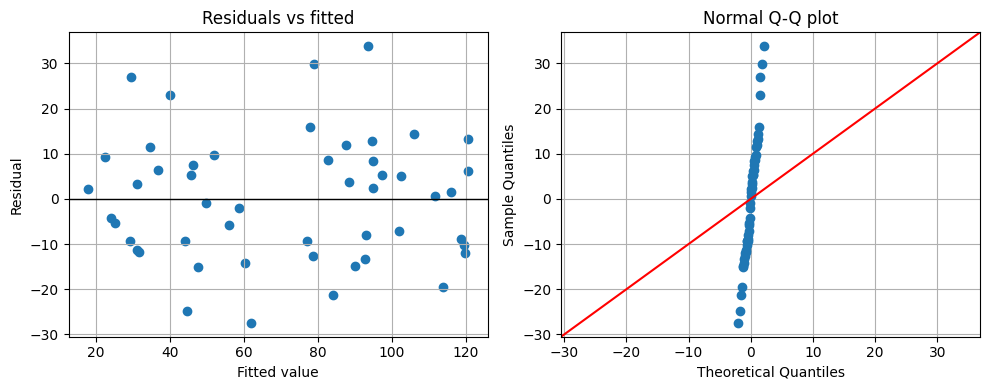

In [8]:
vif_table = pd.DataFrame(
    {
        "variable": X2.columns,
        "VIF": [variance_inflation_factor(X2.to_numpy(), i) for i in range(X2.shape[1])],
    }
)

diagnostic2 = pd.DataFrame(
    {
        "check": [
            "Residual mean",
            "Shapiro-Wilk normality p-value",
            "Durbin-Watson statistic",
            "Breusch-Pagan homoscedasticity p-value",
            "Correlation between X_1 and X_2",
        ],
        "value": [
            model2.resid.mean(),
            stats.shapiro(model2.resid).pvalue,
            durbin_watson(model2.resid),
            het_breuschpagan(model2.resid, X2)[1],
            df2[["X_1", "X_2"]].corr().iloc[0, 1],
        ],
    }
)

display(vif_table)
display(diagnostic2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(model2.fittedvalues, model2.resid)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs fitted")
sm.qqplot(model2.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.show()


**Residual diagnostics.**

- *Zero-mean residuals.* The residual mean is essentially $0$ (up to floating-point precision). This is automatic for any OLS fit that includes an intercept: the normal equations force $\sum_i \hat\varepsilon_i = 0$. It is not informative as a diagnostic on its own, but confirms the fit was computed correctly.
- *Normality.* The Shapiro-Wilk test on the residuals has $p \approx $ `0.565`. Under $H_0$ that residuals are drawn from a normal distribution, observing this test statistic would be unsurprising, so normality is not rejected. The Q-Q plot of residuals also stays close to the reference 45-degree line. This justifies using exact $t$ and $F$ tests for inference.
- *Independence.* The Durbin-Watson statistic is about `2.4`. DW lies in $[0, 4]$; values near $2$ indicate no first-order autocorrelation, values below about $1.5$ suggest positive autocorrelation, and values above about $2.5$ suggest negative autocorrelation. The value here is slightly on the negative side but does not indicate a serious problem, especially because the data are not a time series, so first-order autocorrelation has no natural meaning here.
- *Homoscedasticity.* The Breusch-Pagan test has $p \approx $ `0.642`. Under $H_0$ that residual variance does not depend on the predictors, this is unsurprising, so there is no evidence of heteroscedasticity. The residual-vs-fitted scatter plot is also reasonably patternless.

**Multicollinearity.** This is the main issue with the model.

- The correlation between `X_1` and `X_2` is $r = $ `0.9979`, an essentially perfect linear relationship. The two predictors carry almost the same information.
- Each substantive predictor has $\text{VIF} = $ `233.25`, where

  $$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

  and $R^2_j$ is the coefficient of determination from regressing $X_j$ on the remaining predictors. A VIF of about $233$ means that $R^2_j \approx 1 - 1/233 \approx 0.9957$, i.e. each predictor is almost perfectly explained by the other. Common rules of thumb consider $\text{VIF} > 5$ mild and $\text{VIF} > 10$ problematic; $\text{VIF} = 233$ is severe by any standard. The intercept VIF is computed but not substantively interpreted.
- *Practical consequence.* Multicollinearity inflates the standard errors of the coefficient estimates by a factor of $\sqrt{\text{VIF}} \approx 15$. Predictions ($\hat Y$ values, mean CIs, prediction intervals) remain unbiased and reasonably tight inside the observed predictor range, because the *joint* effect is well estimated. What is poorly estimated is the *partial* contribution of each predictor: signs can flip and magnitudes can be inflated, as we saw. I therefore report the model as a good predictive tool but explicitly avoid claiming separate causal effects for price and rating.

**Estimated error variance and conclusion.** $\hat\sigma^2 = $ `195.49`, $\hat\sigma \approx $ `13.98` pizzas per week. Combining all diagnostics: the OLS assumptions on the error term are reasonable; the predictors are jointly highly informative; the in-sample predictions are accurate; but the individual coefficient interpretations should be treated with caution because of severe collinearity between price and rating.


## Task 3 - Introductory time-series modelling

The data are monthly pizza-restaurant sales indexed by `time` (months $1, \ldots, 50$). The task is to forecast the next six months, i.e. $\text{time} = 51, \ldots, 56$. I use three complementary approaches:

1. A **deterministic polynomial trend model** fitted by OLS. Treats time as a fixed regressor and assumes the trend has a known parametric form (here, quadratic). Forecasts come from extrapolating that fixed curve.
2. **Exponential smoothing** (Holt's linear method). Treats the level and trend as adaptive latent components updated recursively with smoothing parameters. Forecasts come from extrapolating the most recently estimated level and trend.
3. A **Box-Jenkins ARIMA model**. Treats the series as a realisation of a stochastic process, with differencing to remove a unit-root-like trend and an $\text{ARMA}(p, q)$ structure on the differenced series. Forecasts come from the conditional mean of the process given the observed history, plus growing prediction intervals.

### Background concepts used below

**Stationarity.** A time series $\{y_t\}$ is *weakly stationary* if its mean $E[y_t] = \mu$, its variance $\operatorname{Var}(y_t) = \gamma_0$, and its autocovariance $\gamma_k = \operatorname{Cov}(y_t, y_{t-k})$ depend only on the lag $k$, not on $t$. Most classical time-series methods (ARMA modelling, sample autocorrelation estimation, frequency-domain analysis) assume weak stationarity, because otherwise the sample mean and autocovariances do not converge to stable population quantities.

**Unit root and differencing.** A common kind of non-stationarity is a *unit-root process*, the simplest example being the random walk $y_t = y_{t-1} + \varepsilon_t$. Such processes have variance that grows with $t$ and trends that drift without mean reversion. Taking first differences $\Delta y_t = y_t - y_{t-1}$ converts a random walk into white noise; more generally, taking $d$ differences removes a deterministic polynomial trend of degree $d$ and a stochastic unit-root component of order $d$. The "I" (Integrated) in ARIMA refers to this differencing step.

**Box-Jenkins methodology.** The classical workflow is:

1. *Identification.* Inspect the series; if non-stationary, difference until it looks stationary. Examine the sample autocorrelation function (ACF) and partial autocorrelation function (PACF) of the differenced series to choose tentative AR and MA orders.
2. *Estimation.* Fit the chosen ARMA model by (approximate) maximum likelihood.
3. *Diagnostic checking.* Test whether the residuals look like white noise (Ljung-Box portmanteau test, residual ACF), and check normality if prediction intervals are to be reported.
4. *Forecasting.* If diagnostics are clean, forecast and report prediction intervals.

I follow exactly this workflow in the ARIMA section below.

**Why three different approaches?** Each makes different assumptions about how the future is related to the past:

- The deterministic model assumes the underlying trend functional form is correct and will persist into the future. It produces narrow extrapolations but is sensitive to model misspecification.
- Exponential smoothing assumes the trend is locally linear but allows it to drift over time. It is empirically robust on many real series and gives the simplest forecast formula $\hat y_{T+h} = l_T + h \cdot b_T$.
- ARIMA models random shocks explicitly, so prediction intervals widen with the horizon, which is realistic.

Reporting all three lets me cross-check the forecasts against one another and flag any large disagreement that would deserve closer scrutiny.


,time,value
0,1,50.0000
1,2,57.1503
2,3,52.9749
3,4,50.1044
4,5,56.8372


,time,value
45,46,180.5324
46,47,181.9937
47,48,196.5031
48,49,193.1628
49,50,200.0000


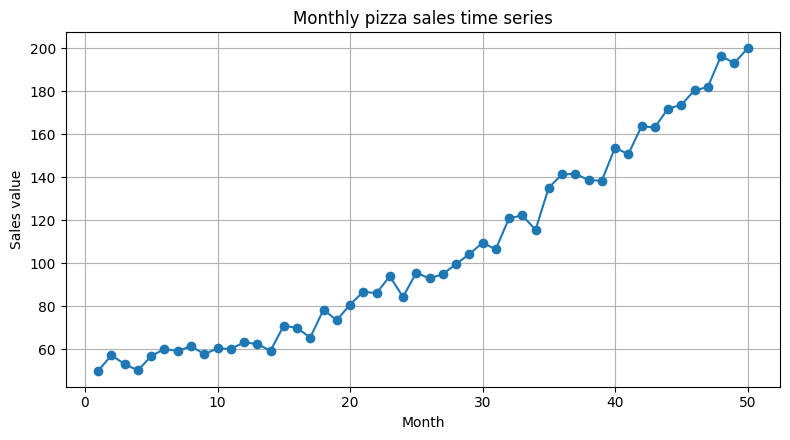

In [9]:
df3 = pd.read_csv("data/data_task3_variant2.csv")
display(df3.head())
display(df3.tail())

fig, ax = plt.subplots()
ax.plot(df3["time"], df3["value"], marker="o")
ax.set_xlabel("Month")
ax.set_ylabel("Sales value")
ax.set_title("Monthly pizza sales time series")
plt.tight_layout()
plt.show()


**What the plot shows.** The series rises from `50` at month 1 to `200` at month 50, an overall four-fold increase. The growth is *nonlinear*: the smoothed level is roughly flat early on (the first few observations fluctuate around $50$-$57$) and rises steeply at the end (the level approximately doubles over the last 12 months). The individual month-to-month differences are noisy and include both positive jumps and drops; the accelerating pattern is in the underlying *trend*, not in every individual increment.

This curvature is the signature of a quadratic-like trend, so a quadratic deterministic model is a natural starting point.

There is no obvious regular pattern of peaks and troughs every 12 months, so a strong annual seasonal component is not visually evident. With only 50 observations - barely four full annual cycles - it would in any case be hard to estimate seasonal effects reliably, which is why I use a non-seasonal ARIMA model below rather than a SARIMA model.

The plot also helps motivate the modelling choices that follow: a deterministic quadratic regression captures the visible curvature, Holt's linear method handles the same trend in a locally adaptive way, and $\text{ARIMA}(1, 2, 1)$ uses second differencing (which exactly removes a quadratic trend) plus short-range $\text{AR}(1)$ and $\text{MA}(1)$ terms to model the residual noise.


In [10]:
trend_candidates = []
for name, formula in [
    ("linear", "value ~ time"),
    ("quadratic", "value ~ time + I(time**2)"),
    ("cubic", "value ~ time + I(time**2) + I(time**3)"),
]:
    m = smf.ols(formula, df3).fit()
    trend_candidates.append({"model": name, "AIC": m.aic, "BIC": m.bic, "adj_R2": m.rsquared_adj})
trend_candidates = pd.DataFrame(trend_candidates)
display(trend_candidates)

trend_model = smf.ols("value ~ time + I(time**2)", df3).fit()
display(fit_ols_table(trend_model))

future = pd.DataFrame({"time": np.arange(51, 57)})
trend_forecast = trend_model.get_prediction(future).summary_frame(alpha=alpha)
trend_forecast.insert(0, "time", future["time"].to_numpy())
display(trend_forecast)

trend_lb = acorr_ljungbox(trend_model.resid, lags=[6, 12], return_df=True)
trend_diag = pd.DataFrame(
    {
        "check": [
            "Residual mean",
            "Estimated error variance",
            "Shapiro p-value",
            "Durbin-Watson",
            "Ljung-Box p-value lag 6",
            "Ljung-Box p-value lag 12",
            "Breusch-Pagan p-value",
        ],
        "value": [
            trend_model.resid.mean(),
            trend_model.mse_resid,
            stats.shapiro(trend_model.resid).pvalue,
            durbin_watson(trend_model.resid),
            trend_lb.loc[6, "lb_pvalue"],
            trend_lb.loc[12, "lb_pvalue"],
            het_breuschpagan(
                trend_model.resid,
                sm.add_constant(pd.DataFrame({"time": df3["time"], "time2": df3["time"] ** 2})),
            )[1],
        ],
    }
)
display(trend_diag)


,model,AIC,BIC,adj_R2
0,linear,386.7573,390.5813,0.9387
1,quadratic,288.9766,294.7127,0.9915
2,cubic,290.5768,298.2248,0.9914


,estimate,std_error,t,p_value,ci_2.5%,ci_97.5%
Intercept,52.5320,1.8681,28.1209,4.7458e-31,48.7739,56.2901
time,0.2174,0.1690,1.2863,2.0462e-01,-0.1226,0.5573
I(time ** 2),0.0555,0.0032,17.2848,5.3316e-22,0.0491,0.0620


,time,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,51,208.0293,1.8681,204.2712,211.7874,198.7301,217.3284
1,52,213.9654,2.0202,209.9012,218.0295,204.5384,223.3924
2,53,220.0125,2.1805,215.6259,224.3990,210.4421,229.5829
3,54,226.1707,2.3487,221.4458,230.8956,216.4405,235.9008
4,55,232.4399,2.5246,227.3611,237.5187,222.5331,242.3467
5,56,238.8201,2.7080,233.3724,244.2679,228.7192,248.9211


,check,value
0,Residual mean,-1.6271e-13
1,Estimated error variance,1.7877e+01
2,Shapiro p-value,7.5235e-01
3,Durbin-Watson,2.3169e+00
4,Ljung-Box p-value lag 6,5.1092e-01
5,Ljung-Box p-value lag 12,3.7524e-01
6,Breusch-Pagan p-value,1.1215e-01


**Model selection among polynomial trends.** I compared linear, quadratic, and cubic trends in `time` using two information criteria and adjusted $R^2$:

- *Linear*: $\text{AIC} = $ `386.76`, $\text{BIC} = $ `390.58`, $R^2_{\text{adj}} = $ `0.939`.
- *Quadratic*: $\text{AIC} = $ `288.98`, $\text{BIC} = $ `294.71`, $R^2_{\text{adj}} = $ `0.992`.
- *Cubic*: $\text{AIC} = $ `290.58`, $\text{BIC} = $ `298.22`, $R^2_{\text{adj}} = $ `0.991`.

The two information criteria are

$$\text{AIC} = 2k - 2 \log L, \qquad \text{BIC} = k \log n - 2 \log L,$$

which both balance fit (via the log-likelihood $L$) against model complexity ($k$, the number of parameters). Lower is better. BIC penalizes parameters more harshly than AIC, especially when $n$ is moderate or large; here both criteria agree and so does $R^2_{\text{adj}}$. The quadratic model is a huge improvement over the linear model (drop of about $98$ AIC units, which is overwhelming evidence on the AIC scale). Adding a cubic term does not improve AIC (small increase) and $R^2_{\text{adj}}$ is essentially unchanged, so I stop at degree $2$.

**Selected deterministic model.**

$$\widehat{\text{value}} = 52.5320 + 0.2174\, t + 0.0555\, t^2, \qquad t = \text{time}.$$

- *Quadratic coefficient* `0.0555`, $t = $ `17.28`, $p \approx $ `5.3e-22`. Highly significant; this is what makes the curve concave upward and is the substantive feature of the trend.
- *Linear coefficient* `0.2174`, $t = $ `1.29`, $p \approx $ `0.205`. Not significant on its own. I keep it anyway because of the *hierarchy principle* in polynomial regression: when a higher-order term is included, all lower-order terms should be kept, even if individually non-significant, so that the model is invariant to translations of the time axis. Dropping the linear term while keeping the quadratic term would also make the vertex of the parabola jump to the origin, which is arbitrary.
- *Intercept* `52.5320`, $t = $ `28.12`, $p \approx $ `4.7e-31`. Predicted value at $t = 0$. Inside the observed range only as the starting point of the fitted curve at month $1$.

**Residual diagnostics for the trend model.**

- *Residual mean $\approx 0$*: automatic for OLS with intercept, as in Task 2.
- *Estimated error variance* $\hat\sigma^2 = $ `17.88`: typical residual size is about $\sqrt{17.88} \approx 4.2$, small relative to the magnitudes of the series.
- *Shapiro-Wilk* on residuals: $p = $ `0.752`, normality not rejected.
- *Durbin-Watson*: `2.32`, close to $2$; no strong evidence of first-order autocorrelation, with a hint of mild negative autocorrelation that is not concerning.
- *Ljung-Box at lags 6 and 12*: $p = $ `0.511` and $p = $ `0.375`. The Ljung-Box test is a portmanteau test for autocorrelation at all lags up to a chosen maximum simultaneously; lag $6$ covers half-year structure and lag $12$ covers annual structure. Both p-values are well above $0.05$, so there is no detectable residual autocorrelation - the quadratic trend has captured the temporal structure adequately.
- *Breusch-Pagan*: $p = $ `0.112`, no evidence of heteroscedasticity (though only marginally above $0.05$, so I note that very mild heteroscedasticity may be present at the edges of the range).

**Forecasts.** Plugging $t = 51, \ldots, 56$ into the fitted equation gives point forecasts increasing from about `208.03` to `238.82`. The 95% confidence intervals for the mean response are narrow (e.g. `[204.27, 211.79]` at month $51$), and the 95% prediction intervals for an individual observation are wider (e.g. `[198.73, 217.33]` at month $51$), reflecting the same mean-vs-individual distinction as in Task 2. The intervals widen slightly with the forecast horizon because the predictor $t$ is moving away from the centre of the observed range, where the variance of a predicted mean is smallest.


In [11]:
y3 = df3["value"].to_numpy()

es_fit = Holt(y3, initialization_method="estimated").fit(optimized=True)
es_resid = y3 - es_fit.fittedvalues

es_params = pd.Series(es_fit.params).drop(labels=["initial_seasons"], errors="ignore")
display(es_params.to_frame("value"))

es_fit_stats = pd.DataFrame(
    {
        "quantity": ["AIC", "SSE", "MAE", "RMSE"],
        "value": [
            es_fit.aic,
            es_fit.sse,
            np.mean(np.abs(es_resid)),
            np.sqrt(np.mean(es_resid**2)),
        ],
    }
)
display(es_fit_stats)

es_forecast = pd.DataFrame({"time": np.arange(51, 57), "forecast": es_fit.forecast(6)})
display(es_forecast)

es_diag = pd.DataFrame(
    {
        "check": ["Residual mean", "Shapiro p-value", "Durbin-Watson", "Ljung-Box p-value lag 6", "Ljung-Box p-value lag 12"],
        "value": [
            es_resid.mean(),
            stats.shapiro(es_resid).pvalue,
            durbin_watson(es_resid),
            acorr_ljungbox(es_resid, lags=[6, 12], return_df=True).loc[6, "lb_pvalue"],
            acorr_ljungbox(es_resid, lags=[6, 12], return_df=True).loc[12, "lb_pvalue"],
        ],
    }
)
display(es_diag)


,value
smoothing_level,0.2574
smoothing_trend,0.2574
smoothing_seasonal,NaN
damping_trend,NaN
initial_level,51.4094
initial_trend,0.7693
use_boxcox,False
lamda,None
remove_bias,False


,quantity,value
0,AIC,170.3796
1,SSE,1286.4148
2,MAE,4.1456
3,RMSE,5.0723


,time,forecast
0,51,205.1689
1,52,210.2918
2,53,215.4147
3,54,220.5376
4,55,225.6605
5,56,230.7834


,check,value
0,Residual mean,1.3139
1,Shapiro p-value,0.8073
2,Durbin-Watson,2.0882
3,Ljung-Box p-value lag 6,0.6260
4,Ljung-Box p-value lag 12,0.4346


**Why Holt's linear method?** The series has a clear trend, so simple exponential smoothing (which only tracks a level) would miss it - its forecasts would be flat after the last observation. Holt's method extends simple ES with a second smoothing equation for the trend slope, giving an *adaptive* linear trend that can change over time. There is no obvious 12-month seasonal pattern in the visualisation and only $4$ full cycles in the data, so Holt-Winters seasonal smoothing would be over-parameterised and is not appropriate here. Holt's method is the simplest exponential-smoothing model that matches the qualitative features of the series.

**The Holt recursions** with smoothing parameters $\alpha$ (level) and $\beta$ (trend), starting from initial level $l_0$ and initial trend $b_0$, are

$$
\begin{aligned}
l_t &= \alpha\, y_t + (1 - \alpha)\, (l_{t-1} + b_{t-1}),\\
b_t &= \beta\, (l_t - l_{t-1}) + (1 - \beta)\, b_{t-1},
\end{aligned}
$$

and the $h$-step-ahead forecast is

$$\hat y_{T+h} = l_T + h \cdot b_T,$$

i.e. a linear extrapolation of the most recent level and trend.

**Fitted parameters.**

- $\alpha \approx $ `0.2574`. A moderate value: each new observation contributes about $26\%$ to the updated level and the previous level provides about $74\%$. Values near $0$ would mean the level barely updates (essentially a fixed mean), and values near $1$ would mean it tracks the latest observation almost exactly.
- $\beta \approx $ `0.2574`. Same moderate behaviour for the trend: the trend slope adapts but does not chase every short-term change.
- $l_0 = $ `51.41`, $b_0 = $ `0.77`. Sensible starting values that match the early observed values of the series.

**Fit quality.**

- $\text{AIC} = $ `170.38` (informative for comparing across exponential-smoothing models; not directly comparable to the OLS trend's AIC because the likelihoods are computed differently).
- $\text{SSE} = $ `1286.41`, $\text{RMSE} = $ `5.07`, $\text{MAE} = $ `4.15`. The typical in-sample error is about $4$-$5$ pizzas per month, comparable to the deterministic trend's residual standard error of about `4.23`.

**Residual diagnostics.**

- *Residual mean* $\approx $ `1.3`. Exponential smoothing does not constrain the residual mean to zero (unlike OLS with an intercept), so a small non-zero mean is normal.
- *Shapiro-Wilk* $p = $ `0.807`, normality not rejected.
- *Durbin-Watson* `2.09`, very close to $2$; no first-order autocorrelation.
- *Ljung-Box* at lags $6$ and $12$: $p = $ `0.626` and $p = $ `0.435`, no detectable residual autocorrelation.

**Forecasts.** Holt's method gives point forecasts `205.17, 210.29, 215.41, 220.54, 225.66, 230.78` for months 51-56. Because Holt's forecast formula is $\hat y_{T+h} = l_T + h \cdot b_T$, these are exactly evenly spaced by $b_T \approx $ `5.12` pizzas per month. The forecast increment is smaller than the deterministic quadratic model's increment (about $6$ pizzas per month and growing) because Holt's local trend is anchored on the recent slope rather than on the accelerating curvature of the whole series.


In [12]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

arima_order = (1, 2, 1)
arima_fit = ARIMA(y3, order=arima_order, trend="n").fit()
burn = arima_order[1]

param_table = pd.DataFrame(
    {
        "estimate": arima_fit.params,
        "std_error": arima_fit.bse,
        "p_value": arima_fit.pvalues,
    },
    index=arima_fit.param_names,
)
display(param_table)

arima_resid = arima_fit.resid[burn:]
arima_diag = pd.DataFrame(
    {
        "check": [
            "AIC",
            "BIC",
            "Residual mean (after burn-in)",
            "Shapiro p-value",
            "Durbin-Watson",
            "Ljung-Box p-value lag 6",
            "Ljung-Box p-value lag 12",
        ],
        "value": [
            arima_fit.aic,
            arima_fit.bic,
            arima_resid.mean(),
            stats.shapiro(arima_resid).pvalue,
            durbin_watson(arima_resid),
            acorr_ljungbox(arima_resid, lags=[6, 12], return_df=True).loc[6, "lb_pvalue"],
            acorr_ljungbox(arima_resid, lags=[6, 12], return_df=True).loc[12, "lb_pvalue"],
        ],
    }
)
display(arima_diag)

arima_forecast = arima_fit.get_forecast(steps=6).summary_frame(alpha=alpha)
arima_forecast.insert(0, "time", np.arange(51, 57))
display(arima_forecast)


,estimate,std_error,p_value
ar.L1,-0.5265,0.1117,2.4422e-06
ma.L1,-0.9019,0.0749,2.2364e-33
sigma2,32.0318,7.4580,1.7470e-05


,check,value
0,AIC,311.4031
1,BIC,317.0167
2,Residual mean (after burn-in),0.8488
3,Shapiro p-value,0.6104
4,Durbin-Watson,2.1622
5,Ljung-Box p-value lag 6,0.3820
6,Ljung-Box p-value lag 12,0.3222


y,time,mean,mean_se,mean_ci_lower,mean_ci_upper
0,51,203.1042,5.6597,192.0114,214.1970
1,52,208.1739,6.5190,195.3968,220.9509
2,53,212.2087,8.2565,196.0262,228.3912
3,54,216.7884,9.4796,198.2087,235.3681
4,55,221.0812,10.9238,199.6710,242.4914
5,56,225.5250,12.2654,201.4854,249.5647


**Model choice.** I fit $\text{ARIMA}(1, 2, 1)$. The notation $(p, d, q)$ means $p$ autoregressive lags, $d$ differencing operations, and $q$ moving-average lags. Writing $B$ for the backshift operator ($B y_t = y_{t-1}$), the full model can be written as

$$\phi(B)\, (1 - B)^d\, y_t = \theta(B)\, \varepsilon_t,$$

where $\phi(B) = 1 - \phi_1 B - \cdots - \phi_p B^p$ is the AR polynomial, $\theta(B) = 1 + \theta_1 B + \cdots + \theta_q B^q$ is the MA polynomial, and $\{\varepsilon_t\}$ is white noise with variance $\sigma^2$. The two building blocks are:

- An **autoregressive** $\text{AR}(p)$ process: $y_t = \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$ - the current value is a linear combination of past values plus a fresh shock. Its theoretical PACF cuts off after lag $p$, while its ACF tails off geometrically.
- A **moving-average** $\text{MA}(q)$ process: $y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$ - the current value is a weighted combination of recent shocks. Its theoretical ACF cuts off after lag $q$, while its PACF tails off.

In practice, the sample ACF and PACF of the (appropriately differenced) series are used to read off plausible orders: a slow-decaying ACF with a sharp PACF cut-off suggests AR; a sharp ACF cut-off with a slow PACF decay suggests MA; both tailing off suggests a mixed $\text{ARMA}(p, q)$. A short-lag $(1, d, 1)$ is a standard starting point when both ACF and PACF tail off after the first lag.

**My choices** for the pizza-sales series:

- $d = 2$. Second differencing of $y_t$ is

  $$(1 - B)^2 y_t = y_t - 2 y_{t-1} + y_{t-2},$$

  which exactly annihilates any deterministic polynomial trend up to degree $2$. This is the same reason I selected a quadratic deterministic trend earlier, expressed in the Box-Jenkins formalism rather than as a fitted curve. After second differencing, the series should be roughly stationary, which is the prerequisite for an $\text{ARMA}$ model.
- $p = 1$. One AR term to capture short-range linear dependence of the differenced series on its own lag.
- $q = 1$. One MA term to capture short-range linear dependence on the previous shock. AR and MA terms model different but complementary types of short-range dynamics, and a parsimonious $(1, d, 1)$ is a standard starting point when both ACF and PACF tail off after the first lag.

I do *not* use a seasonal component. With 50 monthly observations there are only about four full annual cycles, which is too few to estimate seasonal MA coefficients reliably; the visualisation also does not show a clean repeating annual cycle.

**Fitted parameters.**

- $\phi_1 = $ `-0.5265` (`ar.L1`), $p \approx $ `2.4e-06`. Strongly significant; the differenced series shows mean-reverting short-range dependence on its own lag.
- $\theta_1 = $ `-0.9019` (`ma.L1`), $p \approx $ `2.2e-33`. Strongly significant; a large MA(1) coefficient close to $-1$ suggests substantial first-order shock dependence that the AR alone could not capture.
- $\sigma^2 = $ `32.03`, $p \approx $ `1.7e-05`. Estimated innovation variance.

**Residual diagnostics**, computed on the residuals after the first $d = 2$ burn-in observations lost to differencing:

- *Residual mean (after burn-in)* `0.85`. Small relative to typical observation magnitudes (around $50$-$200$) and to the innovation standard deviation $\sqrt{32.03} \approx 5.66$.
- *Shapiro-Wilk* $p = $ `0.610`, normality not rejected. This matters because the prediction intervals reported below are derived under a normality assumption on the innovations.
- *Durbin-Watson* `2.16`, close to $2$; no first-order autocorrelation.
- *Ljung-Box* at lags $6$ and $12$: $p = $ `0.382` and $p = $ `0.322`. The portmanteau test does not detect any remaining autocorrelation, which would be the main signal that $(p, q)$ should be increased; here, parsimony is justified.

$\text{AIC} = $ `311.40`, $\text{BIC} = $ `317.02`. Both are reported by the fit and could be used to compare candidate ARIMA models with the same $d$. The clean Ljung-Box result is the substantive justification for stopping at $(1, 2, 1)$: there is no remaining autocorrelation for higher-order $(p, q)$ terms to explain.

**Forecasts.** The point forecasts for months 51-56 are `203.10, 208.17, 212.21, 216.79, 221.08, 225.53`, with 95% prediction intervals widening from `[192.01, 214.20]` at month $51$ to `[201.49, 249.56]` at month $56$. The widening of the prediction intervals with the horizon is an honest feature of the stochastic-process forecast: each future innovation adds variance, so uncertainty grows. Compare with the deterministic trend, whose prediction-interval widths grow only mildly because the model treats the trend as a known function and only the residual noise adds variance.


Point forecasts for months 51-56:


,quadratic_trend,holt,arima_1_2_1
time,,,
51,208.03,205.17,203.10
52,213.97,210.29,208.17
53,220.01,215.41,212.21
54,226.17,220.54,216.79
55,232.44,225.66,221.08
56,238.82,230.78,225.53


Month-over-month increments:


,quadratic_trend,holt,arima_1_2_1
time,,,
52,5.94,5.12,5.07
53,6.05,5.12,4.03
54,6.16,5.12,4.58
55,6.27,5.12,4.29
56,6.38,5.12,4.44


Forecast summary by method:


,first_forecast (month 51),last_forecast (month 56),total_growth,mean_monthly_increment
quadratic_trend,208.029,238.820,30.791,6.158
holt,205.169,230.783,25.614,5.123
arima_1_2_1,203.104,225.525,22.421,4.484


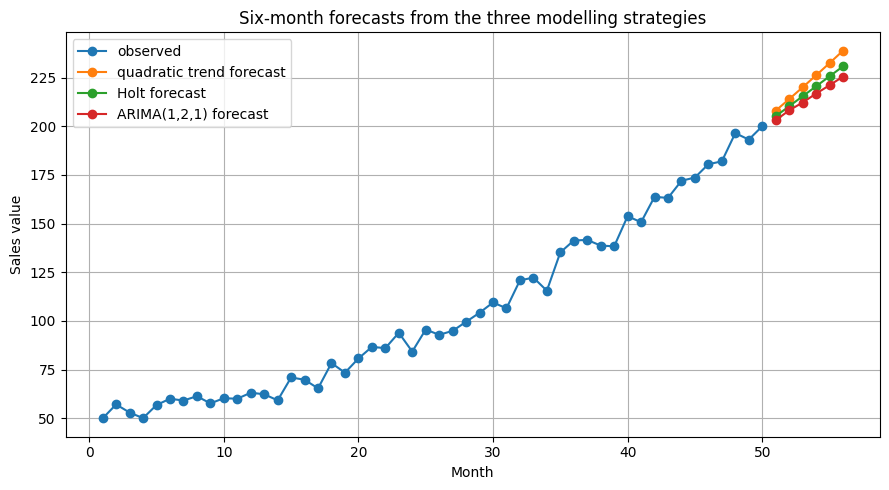

In [13]:
combined_forecasts = pd.DataFrame(
    {
        "time": np.arange(51, 57),
        "quadratic_trend": trend_forecast["mean"].to_numpy(),
        "holt": es_forecast["forecast"].to_numpy(),
        "arima_1_2_1": arima_forecast["mean"].to_numpy(),
    }
)
combined_forecasts_display = combined_forecasts.set_index("time")
print("Point forecasts for months 51-56:")
display(combined_forecasts_display.round(2))

monthly_increments = combined_forecasts_display.diff().dropna()
print("Month-over-month increments:")
display(monthly_increments.round(2))

forecast_summary = pd.DataFrame(
    {
        "first_forecast (month 51)": combined_forecasts_display.iloc[0],
        "last_forecast (month 56)": combined_forecasts_display.iloc[-1],
        "total_growth": combined_forecasts_display.iloc[-1] - combined_forecasts_display.iloc[0],
        "mean_monthly_increment": monthly_increments.mean(),
    }
).round(3)
print("Forecast summary by method:")
display(forecast_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df3["time"], df3["value"], marker="o", label="observed")
ax.plot(combined_forecasts["time"], combined_forecasts["quadratic_trend"], marker="o", label="quadratic trend forecast")
ax.plot(combined_forecasts["time"], combined_forecasts["holt"], marker="o", label="Holt forecast")
ax.plot(combined_forecasts["time"], combined_forecasts["arima_1_2_1"], marker="o", label="ARIMA(1,2,1) forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Sales value")
ax.set_title("Six-month forecasts from the three modelling strategies")
ax.legend()
plt.tight_layout()
plt.show()


**Comparison of the three forecasts.** All three approaches agree on the direction: weekly sales continue to grow over the next six months. The point-forecast table, the increment table, and the summary table printed above quantify how they differ in *magnitude* and *shape*:

- The **deterministic quadratic trend** extrapolates most aggressively because it assumes the entire 50-month curvature continues unchanged. Its forecast increments *grow* month over month (from about $5.9$ to $6.4$ pizzas/month), which is the signature of an accelerating polynomial.
- **Holt's method** extrapolates linearly with a *constant* increment (about $5.12$ pizzas/month, equal to the recursively estimated trend $b_T$), reflecting the recent local slope rather than the global curvature. This is mechanical: Holt's forecast formula is $\hat y_{T+h} = l_T + h \cdot b_T$, so successive increments are all $b_T$ exactly.
- $\text{ARIMA}(1, 2, 1)$ has the smallest and most variable increments (roughly between $4.0$ and $5.1$ pizzas/month), because the AR/MA dynamics on the differenced series imply mean-reverting short-range fluctuations that dampen pure extrapolation.

**Why do they differ?** Each model encodes a different *prior* about the future:

- Quadratic trend: the trend is exactly polynomial and will continue exactly.
- Holt: the level and slope evolve smoothly; the most recent slope is the best estimate of the next one.
- ARIMA: the second-differenced series is a short-memory stationary process; cumulative future shocks add variance, so forecasts shrink slightly toward the local mean of the differences.

**Which one to report?** The assignment asks for all three, which is what I report. If I had to pick one operational forecast for, say, a sales-planning decision, I would choose Holt or $\text{ARIMA}(1, 2, 1)$ over the deterministic trend, because both are *adaptive* and less reliant on the assumption that the strong observed curvature persists indefinitely. $\text{ARIMA}(1, 2, 1)$ has the extra advantage of giving explicit, theoretically grounded prediction intervals that widen with the horizon (printed earlier as `mean_ci_lower` / `mean_ci_upper` in the ARIMA forecast frame), which is what a planner needs to budget for downside risk.

**Conclusion for Task 3.** Across three modelling strategies the forecasts are consistent in direction and broadly comparable in magnitude. The summary table above shows the total six-month growth per method (about `30.8`, `25.6`, and `22.4` pizzas for quadratic, Holt, and ARIMA respectively), giving a gap of about $13$ pizzas between the most and least aggressive forecast at month $56$. This gap is well inside one ARIMA prediction-interval half-width (about $24$ pizzas), so the three approaches are statistically compatible: all three would be defensible operational forecasts within their respective uncertainty bands.
